# Demo of KYA face identification - MLP neural network training and Leo transpilation

## Overview of steps
* Ensure Leo and Python library installation
* Add your own image (optional)
* Load the dataset and extract the features
* Split into a training and test dataset
* Train the model
* Evaluate the model
* PCA feature transformation
* Re-train and evaluate the model
* Transpilation to Leo
* Test execution of the Leo program
* Deployment of the Leo program

## TODO Ensure Leo and Python library installation
For this Jupyter notebook to run successfully, you need to ensure Leo and selected Python libraries are installed. If you haven't done already ...

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import face_recognition
import pandas as pd
import numpy as np

/opt/homebrew/lib/python3.13/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Add your own image (optional)
In this notebook, we use 3 JPG images of Albert Einstein as the positive class.
You can replace these with 3 JPG images of yourself - place the files `1.jpg`, `2.jpg`, `3.jpg` in the folder.

The following code ensures the files inside the positive class folder are correctly set up.

In [2]:
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

positive_dir_path = os.path.join(cwd, 'face_images', 'positive')
if not os.path.isdir(positive_dir_path):
    raise FileNotFoundError(f"Directory not found: {positive_dir_path}")

Current working directory: /Users/kp/dev/python-sdk3/zkml-research/KYA_face


In [3]:
files = sorted(f for f in os.listdir(positive_dir_path)
               if os.path.isfile(os.path.join(positive_dir_path, f)))
expected = ['1.jpg', '2.jpg', '3.jpg']
if files != expected:
    raise ValueError(f"Expected {expected}, but found {files}")
print(f"Found expected files: {files}")

Found expected files: ['1.jpg', '2.jpg', '3.jpg']


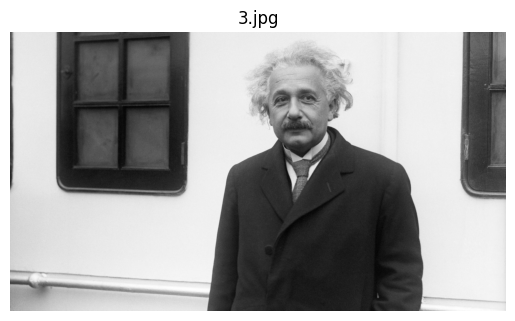

In [4]:
image_path = os.path.join(positive_dir_path, '3.jpg')
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title('3.jpg')
plt.show()

## Load the dataset and extract the features

In [5]:
def iter_face_embeddings(directory: Path, label: int):
    """
    Yields dicts with keys:
      - 'filename': str
      - 'label':    int (1=positive, 0=negative)
      - 'embedding': np.ndarray shape (128,)
    """
    for img_path in sorted(directory.iterdir()):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        image = face_recognition.load_image_file(str(img_path))
        encs = face_recognition.face_encodings(image)
        if not encs:
            print(f"[warn] no face in {img_path.name}, skipping")
            continue
        yield {
            'filename': img_path.name,
            'label': label,
            'embedding': encs[0]
        }

In [6]:
# also define negative_dir_path
negative_dir_path = os.path.join(cwd, 'face_images', 'negative')

# collect records
records = list(iter_face_embeddings(Path(positive_dir_path), label=1)) \
        + list(iter_face_embeddings(Path(negative_dir_path), label=0))

# DataFrame with metadata + raw embeddings
df = pd.DataFrame(records)

# stack embeddings into an (n_samples × 128) array
X = np.stack(df['embedding'].values)
y = df['label'].values

[warn] no face in 24_0_2_20170116174324623.jpg, skipping
[warn] no face in 6_0_0_20170110213600515.jpg, skipping


In [7]:
df.head()

,filename,label,embedding
0,1.jpg,1,"[-0.13916254043579102, 0.06765440106391907, 0...."
1,2.jpg,1,"[-0.10024195909500122, 0.060482949018478394, 0..."
2,3.jpg,1,"[-0.1615755558013916, 0.07210954278707504, 0.0..."
3,12_0_0_20170110215739155.jpg,0,"[-0.0820397362112999, 0.027357343584299088, 0...."
4,14_0_1_20170117141604244.jpg,0,"[-0.21727801859378815, 0.1069168969988823, 0.0..."


## Split into a training and test dataset

In [8]:
from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier

# 1) Positive class: first two → train, last one → test
df_pos = df[df['label'] == 1].reset_index(drop=True)
train_pos = df_pos.iloc[[0, 1]]   # 1.jpg, 2.jpg
test_pos  = df_pos.iloc[[2]]      # 3.jpg

# 2) Negative class: random 2/3 train, 1/3 test (seed=42)
df_neg = df[df['label'] == 0].reset_index(drop=True)
train_neg, test_neg = train_test_split(
    df_neg,
    test_size=1/3,
    random_state=42,
    shuffle=True
)

# 3) Combine back together
train_df = pd.concat([train_pos, train_neg]).reset_index(drop=True)
test_df  = pd.concat([test_pos,  test_neg]).reset_index(drop=True)

# 4) Extract X / y arrays
X_train = np.stack(train_df['embedding'].values)
y_train = np.eye(2)[train_df['label'].values]

X_test  = np.stack(test_df['embedding'].values)
y_test  = np.eye(2)[test_df['label'].values]

# 5) Quick sanity check
print(f"Training samples: {len(train_df)}  (pos={len(train_pos)}, neg={len(train_neg)})")
print(f" Testing samples: {len(test_df)}  (pos={len(test_pos)}, neg={len(test_neg)})")
train_df[['filename','label']], test_df[['filename','label']]

Training samples: 67  (pos=2, neg=65)
 Testing samples: 34  (pos=1, neg=33)


(                        filename  label
 0                          1.jpg      1
 1                          2.jpg      1
 2   58_0_3_20170119211659305.jpg      0
 3   18_1_0_20170109213623055.jpg      0
 4   32_0_1_20170113133956457.jpg      0
 ..                           ...    ...
 62  40_0_3_20170117154652454.jpg      0
 63  46_1_1_20170116223430582.jpg      0
 64  25_1_0_20170117142815331.jpg      0
 65  68_0_0_20170105173736735.jpg      0
 66  35_0_3_20170117154729846.jpg      0
 
 [67 rows x 2 columns],
                         filename  label
 0                          3.jpg      1
 1   40_1_2_20170116161916676.jpg      0
 2   30_0_1_20170113195438285.jpg      0
 3   87_0_0_20170111222120006.jpg      0
 4   26_0_1_20170113151702303.jpg      0
 5   54_0_0_20170104165859441.jpg      0
 6   54_1_0_20170117191133235.jpg      0
 7   42_0_0_20170112220250648.jpg      0
 8   31_1_1_20170112231608655.jpg      0
 9   23_0_3_20170119164041958.jpg      0
 10  12_0_0_20170110215739155.j

In [9]:
from sklearn.preprocessing import StandardScaler

# 1) Initialize scaler
scaler = StandardScaler()

# 2) Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3) (Optional) check means/vars
print("Train mean (first 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Train std  (first 5 features):", X_train_scaled.std(axis=0)[:5])

Train mean (first 5 features): [ 2.64092231e-17  5.30255773e-17  1.63012224e-16 -4.97114787e-17
 -9.44518096e-17]
Train std  (first 5 features): [1. 1. 1. 1. 1.]


## Train the model

In [10]:
clf_large = MLPClassifier(hidden_layer_sizes=(65,), max_iter=100, random_state=42)
clf_large.fit(X_train_scaled, y_train)

/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(65,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


## Evaluate the model

In [11]:
print("Train accuracy:", clf_large.score(X_train_scaled, y_train))
print("Test accuracy:", clf_large.score(X_test_scaled,  y_test))

Train accuracy: 1.0
Test accuracy: 1.0


## PCA feature transformation

In [12]:
# Cell X: PCA dimensionality reduction
from sklearn.decomposition import PCA

# 1) Initialize PCA (fit only on training data)
pca = PCA(n_components=32, random_state=42)

# 2) Fit on X_train and transform both train & test
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# 3) Check shapes to confirm reduction
print("X_train_pca shape:", X_train_pca.shape)  # (n_train_samples, 32)
print("X_test_pca  shape:", X_test_pca.shape)   # (n_test_samples, 32)

# (Optional) Examine how much variance is retained
explained = pca.explained_variance_ratio_.cumsum()
print("Cumulative explained variance (first 5 components):", explained[:5])
print("Total variance retained:", explained[-1])

X_train_pca shape: (67, 32)
X_test_pca  shape: (34, 32)
Cumulative explained variance (first 5 components): [0.13134312 0.25755996 0.33214079 0.39133033 0.44493415]
Total variance retained: 0.9277635063358127


In [13]:
# Cell Y: Re-standardize PCA outputs before model training
from sklearn.preprocessing import StandardScaler

# 1) Initialize a new scaler
scaler_pca = StandardScaler()

# 2) Fit on the PCA‐transformed training data, then apply to both
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca)

# 3) Quick sanity check: zero mean/unit var on train
print("Post-PCA train means (first 5 comps):", 
      X_train_pca_scaled.mean(axis=0)[:5])
print("Post-PCA train stds  (first 5 comps):", 
      X_train_pca_scaled.std(axis=0)[:5])

Post-PCA train means (first 5 comps): [-4.97114787e-18  1.65704929e-17 -6.62819716e-18 -2.89983626e-17
  3.31409858e-18]
Post-PCA train stds  (first 5 comps): [1. 1. 1. 1. 1.]


## Re-train and evaluate the model

In [14]:
clf_small = MLPClassifier(hidden_layer_sizes=(17,), max_iter=100, random_state=42)
clf_small.fit(X_train_pca_scaled, y_train)

/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(17,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


In [15]:
print("Train accuracy:", clf_small.score(X_train_pca_scaled, y_train))
print("Test accuracy:", clf_small.score(X_test_pca_scaled,  y_test))

Train accuracy: 0.9850746268656716
Test accuracy: 0.9117647058823529


## Transpilation to Leo

In [16]:
from zkml import LeoTranspiler

# Transpile the NN into Leo code
lt = LeoTranspiler(
    model=clf_small
)
leo_project_path = os.path.join(os.getcwd(), "/tmp/mnist")
leo_project_name = "sklearn_mlp_mnist_1"
lt.to_leo(
    path=leo_project_path, project_name=leo_project_name, fixed_point_scaling_factor=16
)


In [27]:
#print(y_test[0])
#print(y_test[1])
#print(y_test[2])


# Compute the accuracy of the Leo program and the Python program on the test set
num_test_samples = len(X_test_pca_scaled)

# let's limit the number of test stamples to 10 to make the computation faster
num_test_samples = min(num_test_samples, 1)
#test_features = X_test_pca[:num_test_samples]
test_features = X_test_pca_scaled[0:1]

python_predictions = clf_small.predict(test_features)

print("python_predictions", python_predictions)

proba_list = clf_small.predict_proba(test_features)

print("proba_list", proba_list)

leo_predictions = np.zeros(num_test_samples)
for i in range(num_test_samples):
    lc = lt.run(input=test_features[i])
    print("decimal output", lc.output_decimal)
    print("output", lc.output)
    print("input", lc.input)
    # compute softmax probabilities
    logits = lc.output_decimal            # Leo → Python floats
    sigmoid_probs_0 = 1/(1+np.exp(-logits[0])) # element-wise
    sigmoid_probs_1 = 1/(1+np.exp(-logits[1])) # element-wise
    print("Sigmoid output:", (sigmoid_probs_0, sigmoid_probs_1))
    leo_predictions[i] = np.argmax(lc.output_decimal)

print(f"Constraints: {lc.circuit_constraints}")
print(f"Runtime for one instance: {lc.runtime} seconds")

print(leo_predictions)

python_predictions [[0 1]]
proba_list [[0.43960105 0.53485759]]
decimal output [-0.27880859375, 0.108154296875]
output [-1142, 443]
input ['{ x0: -21i64, x1: 6i64 }', '{ x0: 13i64, x1: 24i64 }', '{ x0: 0i64, x1: -11i64 }', '{ x0: -7i64, x1: -18i64 }', '{ x0: 3i64, x1: -17i64 }', '{ x0: 12i64, x1: -15i64 }', '{ x0: -15i64, x1: 28i64 }', '{ x0: -1i64, x1: 2i64 }', '{ x0: 8i64, x1: 10i64 }', '{ x0: 29i64, x1: -2i64 }', '{ x0: 2i64, x1: 8i64 }', '{ x0: 9i64, x1: -8i64 }', '{ x0: 9i64, x1: 24i64 }', '{ x0: 2i64, x1: -5i64 }', '{ x0: -8i64, x1: 7i64 }', '{ x0: -15i64, x1: -8i64 }']
Sigmoid output: (0.4307458893450617, 0.5270122483693945)
Constraints: 269822
Runtime for one instance: 2.605588436126709 seconds
[1.]


In [ ]:
# ...
a = 5/0

## Download the dataset

In [ ]:
# URLs and filenames
file_info = [
    (
        "http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz",
        "train-images-idx3-ubyte.gz",
    ),
    (
        "http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz",
        "train-labels-idx1-ubyte.gz",
    ),
    (
        "http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz",
        "t10k-images-idx3-ubyte.gz",
    ),
    (
        "http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz",
    ),
]

folder_name = "tmp/mnist"
folder_path = os.path.join(os.getcwd(), folder_name)

os.makedirs(folder_path, exist_ok=True)  # Create folder if it doesn't exist

# Download and extract each file
for url, file_name in file_info:
    path_to_save = os.path.join(folder_path, file_name)
    download_and_extract_dataset(url, path_to_save, folder_path)

## Define function to read the dataset

In [ ]:
import numpy as np


def read_idx3_ubyte_image_file(filename):
    """Read IDX3-ubyte formatted image data."""
    with open(filename, "rb") as f:
        magic_num = int.from_bytes(f.read(4), byteorder="big")
        num_images = int.from_bytes(f.read(4), byteorder="big")
        num_rows = int.from_bytes(f.read(4), byteorder="big")
        num_cols = int.from_bytes(f.read(4), byteorder="big")

        if magic_num != 2051:
            raise ValueError(f"Invalid magic number: {magic_num}")

        images = np.zeros((num_images, num_rows, num_cols), dtype=np.uint8)

        for i in range(num_images):
            for r in range(num_rows):
                for c in range(num_cols):
                    pixel = int.from_bytes(f.read(1), byteorder="big")
                    images[i, r, c] = pixel

    return images


def read_idx1_ubyte_label_file(filename):
    """Read IDX1-ubyte formatted label data."""
    with open(filename, "rb") as f:
        magic_num = int.from_bytes(f.read(4), byteorder="big")
        num_labels = int.from_bytes(f.read(4), byteorder="big")

        if magic_num != 2049:
            raise ValueError(f"Invalid magic number: {magic_num}")

        labels = np.zeros(num_labels, dtype=np.uint8)

        for i in range(num_labels):
            labels[i] = int.from_bytes(f.read(1), byteorder="big")

    return labels

## Read the dataset

In [ ]:
folder_path = os.path.join(
    os.getcwd(), folder_name
)  # Adjust this path to where you stored the files

train_images = read_idx3_ubyte_image_file(
    os.path.join(folder_path, "train-images-idx3-ubyte")
)
train_labels = read_idx1_ubyte_label_file(
    os.path.join(folder_path, "train-labels-idx1-ubyte")
)
test_images = read_idx3_ubyte_image_file(
    os.path.join(folder_path, "t10k-images-idx3-ubyte")
)
test_labels = read_idx1_ubyte_label_file(
    os.path.join(folder_path, "t10k-labels-idx1-ubyte")
)

print(
    f"Shape of train_images: {train_images.shape}"
)  # Should output "Shape of train_images: (60000, 28, 28)"
print(
    f"Shape of train_labels: {train_labels.shape}"
)  # Should output "Shape of train_labels: (60000,)"
print(
    f"Shape of test_images: {test_images.shape}"
)  # Should output "Shape of test_images: (10000, 28, 28)"
print(
    f"Shape of test_labels: {test_labels.shape}"
)  # Should output "Shape of test_labels: (10000,)"

## Convert the datasets to PyTorch tensors, and get a validation set
(We use PyTorch instead of sci-kit learn to train sparse neural networks with L1 regularization)

In [ ]:
# convertto pytorch tensors
import torch

train_images_tensor_initial = torch.from_numpy(train_images).float()
train_labels_tensor_initial = torch.from_numpy(train_labels).long()
test_images_tensor = torch.from_numpy(test_images).float()
test_labels_tensor = torch.from_numpy(test_labels).long()

# seed the random number generator
torch.manual_seed(0)

# shuffle the training dataset
indices = torch.randperm(train_images_tensor_initial.shape[0])
train_images_tensor_shuffled = train_images_tensor_initial[indices]
train_labels_tensor_shuffled = train_labels_tensor_initial[indices]

# get a 10% validation set
validation_size = int(train_images_tensor_shuffled.shape[0] * 0.1)
validation_images_tensor = train_images_tensor_shuffled[:validation_size]
validation_labels_tensor = train_labels_tensor_shuffled[:validation_size]
train_images_tensor = train_images_tensor_shuffled[validation_size:]
train_labels_tensor = train_labels_tensor_shuffled[validation_size:]

In [ ]:
print("Train labels tensor shape:", train_labels_tensor.shape)
print("Validation labels tensor shape:", validation_labels_tensor.shape)
print("Test labels tensor shape:", test_labels_tensor.shape)

## Extract feature representations of the dataset

(We transform the bounding box images to 12x12 images, defined by the new_size variable. There is a trade-off in circuit constraints and ML model accuracy. You can increase the image size which will lead to a higher accuracy at the cost of more circuit constraints and thus longer proving times.)

In [ ]:
import numpy as np


def get_bounding_box(img):
    """
    Extract the bounding box from an MNIST image.

    Args:
        img (np.ndarray): 2D numpy array representing the MNIST image.

    Returns:
        (np.ndarray): Cropped image with the bounding box.
    """

    # convert torch image to numpy array
    img = img.numpy()

    # Find the rows and columns where the image has non-zero pixels
    rows = np.any(img, axis=1)
    cols = np.any(img, axis=0)

    # Find the first and last row and column indices where the image has non-zero pixels
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Return the cropped image
    return img[rmin : rmax + 1, cmin : cmax + 1]

In [ ]:
import cv2


def get_resized_datasets(
    train_images_tensor, validation_images_tensor, test_images_tensor, new_size
):
    num_train = len(train_images_tensor)
    num_test = len(test_images_tensor)
    num_val = len(validation_images_tensor)

    train_images_tensor_resized = np.zeros((num_train, new_size**2))
    validation_images_tensor_resized = np.zeros((num_val, new_size**2))
    test_images_tensor_resized = np.zeros((num_test, new_size**2))

    for i in range(num_train):
        cropped_image = get_bounding_box(train_images_tensor[i].reshape(28, 28))
        cropped_image_uint8 = np.clip(cropped_image, 0, 255).astype(np.uint8)
        resized_image = cv2.resize(
            cropped_image_uint8, (new_size, new_size), interpolation=cv2.INTER_AREA
        )
        train_images_tensor_resized[i, :] = resized_image.flatten()

    for i in range(num_val):
        cropped_image = get_bounding_box(validation_images_tensor[i].reshape(28, 28))
        cropped_image_uint8 = np.clip(cropped_image, 0, 255).astype(np.uint8)
        resized_image = cv2.resize(
            cropped_image_uint8, (new_size, new_size), interpolation=cv2.INTER_AREA
        )
        validation_images_tensor_resized[i, :] = resized_image.flatten()

    for i in range(num_test):
        cropped_image = get_bounding_box(test_images_tensor[i].reshape(28, 28))
        cropped_image_uint8 = np.clip(cropped_image, 0, 255).astype(np.uint8)
        resized_image = cv2.resize(
            cropped_image_uint8, (new_size, new_size), interpolation=cv2.INTER_AREA
        )
        test_images_tensor_resized[i, :] = resized_image.flatten()

    return (
        train_images_tensor_resized,
        validation_images_tensor_resized,
        test_images_tensor_resized,
    )

In [ ]:
new_size = 12
train_images_resized, val_images_resized, test_images_resized = get_resized_datasets(
    train_images_tensor, validation_images_tensor, test_images_tensor, new_size
)

## Let's compute the features

In [ ]:
def compute_haar_features(image):
    # raise value error if the image is not square
    if image.shape[0] != image.shape[1]:
        raise ValueError("The input image must be square.")

    features = []

    # Sliding window
    for i in range(0, image.shape[0], 3):  # Slide vertically with a step of 3
        for j in range(0, image.shape[0], 3):  # Slide horizontally with a step of 3

            if i + 6 > image.shape[0] or j + 6 > image.shape[0]:
                continue

            # Extract 6x6 window
            window = image[i : i + 6, j : j + 6]

            # Horizontal feature
            horizontal_feature_value = np.sum(window[0:3, :]) - np.sum(window[3:6, :])

            # Vertical feature
            vertical_feature_value = np.sum(window[:, 0:3]) - np.sum(window[:, 3:6])

            features.append(horizontal_feature_value)
            features.append(vertical_feature_value)

    return np.array(features)


def aspect_ratio(image, threshold=0.5):
    # Threshold the image to create a binary representation
    bin_image = image > threshold
    # Find the bounding box
    row_indices, col_indices = np.nonzero(bin_image)
    max_row, min_row = np.max(row_indices), np.min(row_indices)
    max_col, min_col = np.max(col_indices), np.min(col_indices)

    # Calculate the aspect ratio of the bounding box
    width = max_col - min_col + 1
    height = max_row - min_row + 1

    if height == 0:  # To avoid division by zero
        return 1.0

    return width / height


from scipy.ndimage import label


def num_regions_below_threshold(image, threshold=0.5):
    # Threshold the image so that pixels below the threshold are set to 1
    # and those above the threshold are set to 0.
    bin_image = image < threshold

    # Use connected components labeling
    labeled_array, num_features = label(bin_image)

    # Return the number of unique regions
    # (subtracting 1 as one of the labels will be the background)
    return num_features

In [ ]:
# compute datasets

num_train = len(train_images_tensor)
num_val = len(validation_images_tensor)
num_test = len(test_images_tensor)

aspect_ratio_train = np.zeros(num_train)
aspect_ratio_val = np.zeros(num_val)
aspect_ratio_test = np.zeros(num_test)

num_white_regions_train = np.zeros(num_train)
num_white_regions_val = np.zeros(num_val)
num_white_regions_test = np.zeros(num_test)

haar_1 = compute_haar_features(train_images_resized[0].reshape(new_size, new_size))
len_haar_features = len(haar_1)

haar_train = np.zeros((num_train, len_haar_features))
haar_val = np.zeros((num_val, len_haar_features))
haar_test = np.zeros((num_test, len_haar_features))

for i in range(num_train):
    aspect_ratio_train[i] = aspect_ratio(train_images_tensor[i].reshape(28, 28).numpy())
    num_white_regions_train[i] = num_regions_below_threshold(
        train_images_tensor[i].reshape(28, 28)
    )
    haar_train[i, :] = compute_haar_features(
        train_images_resized[i, :].reshape(new_size, new_size)
    )

for i in range(num_val):
    aspect_ratio_val[i] = aspect_ratio(
        validation_images_tensor[i].reshape(28, 28).numpy()
    )
    num_white_regions_val[i] = num_regions_below_threshold(
        validation_images_tensor[i].reshape(28, 28)
    )
    haar_val[i, :] = compute_haar_features(
        val_images_resized[i, :].reshape(new_size, new_size)
    )

for i in range(num_test):
    aspect_ratio_test[i] = aspect_ratio(test_images_tensor[i].reshape(28, 28).numpy())
    num_white_regions_test[i] = num_regions_below_threshold(
        test_images_tensor[i].reshape(28, 28)
    )
    haar_test[i, :] = compute_haar_features(
        test_images_resized[i, :].reshape(new_size, new_size)
    )

## Take a look at the images, and the computed features

In [ ]:
image_id = 0

image = train_images_tensor[image_id].reshape(28, 28)

print("Original image")

import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.show()

print("Image shape", image.shape)
print("Label", train_labels_tensor[image_id])

print("Resized image")

image_resized = train_images_resized[image_id].reshape(new_size, new_size)

plt.imshow(image_resized, cmap="gray")
plt.show()

print("Image shape", image_resized.shape)

print("Haar features:", haar_train[image_id, :])
print("Shape of Haar features:", haar_train[image_id, :].shape)

print("Aspect ratio:", aspect_ratio_train[image_id])
print("Number of white regions:", num_white_regions_train[image_id])

## Let's merge all features into one dataset

In [ ]:
# compute datasets

train_features = np.zeros((num_train, len_haar_features + 2))
val_features = np.zeros((num_val, len_haar_features + 2))
test_features = np.zeros((num_test, len_haar_features + 2))

for i in range(num_train):
    train_features[i, :] = np.hstack(
        (haar_train[i, :], aspect_ratio_train[i], num_white_regions_train[i])
    )

for i in range(num_val):
    val_features[i, :] = np.hstack(
        (haar_val[i, :], aspect_ratio_val[i], num_white_regions_val[i])
    )

for i in range(num_test):
    test_features[i, :] = np.hstack(
        (haar_test[i, :], aspect_ratio_test[i], num_white_regions_test[i])
    )

In [ ]:
print("Shape of training features:", train_features.shape)
print("First training feature vector:", train_features[0, :])

## Normalize the dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_features_normalized = torch.tensor(scaler.fit_transform(train_features)).float()
val_features_normalized = torch.tensor(scaler.transform(val_features)).float()
test_features_normalized = torch.tensor(scaler.transform(test_features)).float()

In [ ]:
print("First training feature vector (normalized):", train_features_normalized[0, :])

## Define the neural network and the training and test function

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score


def evaluate_model(model):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        test_outputs = model(test_features_normalized)
        _, predicted = torch.max(test_outputs.data, 1)
        accuracy = accuracy_score(test_labels, predicted.numpy())
        print("Accuracy:", accuracy)
        return accuracy


# Define the PyTorch neural network
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def train(model):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop with L1 regularization
    lambda_l1 = 0.0001  # L1 regularization coefficient

    validation_losses = []
    epoch = 0

    model_states = []

    while True:
        optimizer.zero_grad()
        outputs = model(train_features_normalized)

        loss = criterion(outputs, train_labels_tensor)

        # Add L1 regularization
        l1_reg = torch.tensor(0.0, requires_grad=True)
        for param in model.parameters():
            l1_reg = l1_reg + torch.norm(param, 1)
        loss += lambda_l1 * l1_reg

        loss.backward()
        optimizer.step()

        # Print progress
        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}], Loss: {loss.item():.4f}, validation loss: {validation_losses[-1]:.4f}"
            )

        # store model state
        model_states.append(model.state_dict())

        # Compute validation loss
        with torch.no_grad():
            outputs = model(val_features_normalized)
            loss = criterion(outputs, validation_labels_tensor)
            validation_losses.append(loss.item())

        # Check for early stopping if no improvement in validation loss in last 10 epochs
        if epoch > 10 and validation_losses[-1] > validation_losses[-10]:
            print("Early stopping")
            break

        epoch += 1

    best_model_state = model_states[np.argmin(validation_losses)]
    model.load_state_dict(best_model_state)
    validation_loss_of_best_model = validation_losses[np.argmin(validation_losses)]

    return model, epoch, validation_loss_of_best_model

## Let's create and train a model

In [ ]:
# Hyperparameters
input_dim = train_features_normalized.shape[1]
output_dim = len(set(train_labels))  # Assuming train_labels are class indices
hidden_dim = (input_dim + output_dim) // 2

# Instantiate the model
model = SimpleNN(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)

In [ ]:
# Train the model
model, epochs, val_loss = train(model)

In [ ]:
evaluate_model(model)

## Let's prune the model

In [ ]:
def prune_pytorch_network(
    model, weight_threshold=1e-1, bias_threshold=1e-1
):  # noqa: D103
    num_weights = 0
    num_weights_already_zero = 0
    num_changed_weights = 0
    num_biases = 0
    num_biases_already_zero = 0
    num_changed_biases = 0

    # Pruning the weights
    for name, param in model.named_parameters():
        if "weight" in name:
            flattened_weights = param.data.view(-1)
            for j, weight in enumerate(flattened_weights):
                if weight == 0:
                    num_weights_already_zero += 1
                elif abs(weight) < weight_threshold:
                    flattened_weights[j] = 0
                    num_changed_weights += 1
                num_weights += 1
            param.data = flattened_weights.view(param.data.shape)
        elif "bias" in name:
            flattened_biases = param.data.view(-1)
            for j, bias in enumerate(flattened_biases):
                if bias == 0:
                    num_biases_already_zero += 1
                elif abs(bias) < bias_threshold:
                    flattened_biases[j] = 0
                    num_changed_biases += 1
                num_biases += 1
            param.data = flattened_biases.view(param.data.shape)

    # Set gradients of pruned weights to zero
    def zero_gradients_hook(grad):
        return grad * (grad != 0)

    hooks = []
    for name, param in model.named_parameters():
        if "weight" in name or "bias" in name:
            hooks.append(param.register_hook(zero_gradients_hook))

    print(f"Number of weight parameters: {num_weights}")  # noqa: T201
    print(f"Number of weights already zero: {num_weights_already_zero}")  # noqa: T201
    print(f"Number of changed weight parameters: {num_changed_weights}")  # noqa: T201
    print(f"Number of bias parameters: {num_biases}")  # noqa: T201
    print(f"Number of biases already zero: {num_biases_already_zero}")  # noqa: T201
    print(f"Number of changed bias parameters: {num_changed_biases}")  # noqa: T201
    print(  # noqa: T201
        f"Percentage of weights pruned: {num_changed_weights / num_weights * 100:.2f}%"
    )
    print(  # noqa: T201
        f"Percentage of biases pruned: {num_changed_biases / num_biases * 100:.2f}%"
    )
    print(  # noqa: T201
        f"Remaining number of non-zero weights: {num_weights - num_changed_weights}"
    )
    print(  # noqa: T201
        f"Remaining number of non-zero biases: {num_biases - num_changed_biases}"
    )

    return model, hooks

In [ ]:
import copy

model_pruned = copy.deepcopy(model)
model_pruned, hooks = prune_pytorch_network(model_pruned, 1e-1, 1e-1)

_ = evaluate_model(model_pruned)

## Let's have a loop of fine-tuning, pruning, and evaluating

In [ ]:
i = 0
val_loss_new = val_loss
model_to_prune = copy.deepcopy(model)

while True:
    print(f"Iteration {i}")
    model_pruned = copy.deepcopy(model_to_prune)
    model_pruned, _ = prune_pytorch_network(model_pruned, 1e-1, 1e-1)
    val_loss_old = val_loss_new

    model_to_prune = copy.deepcopy(model_pruned)
    print("Now training")
    model_to_prune, _, val_loss_new = train(model_to_prune)

    if val_loss_new > val_loss_old:
        print("Early stopping")
        break

    i += 1

accuracy = evaluate_model(model_pruned)

## Let's convert this model to a scikit-learn MLP model

In [ ]:
from sklearn.neural_network import MLPClassifier


def pytorch_to_sklearn(pytorch_model):

    # Extract weights and biases from PyTorch model
    fc1_weight = pytorch_model.fc1.weight.data
    fc1_bias = pytorch_model.fc1.bias.data
    fc2_weight = pytorch_model.fc2.weight.data
    fc2_bias = pytorch_model.fc2.bias.data

    # Get the sizes for initialization
    input_size = fc1_weight.shape[1]
    hidden_size = fc1_weight.shape[0]
    output_size = fc2_weight.shape[0]

    # Initialize sklearn MLP
    sklearn_mlp = MLPClassifier(
        hidden_layer_sizes=(hidden_size,), activation="relu", max_iter=1
    )

    # To ensure the model doesn't change the weights during the dummy fit, we set warm_start=True
    sklearn_mlp.warm_start = True

    # Dummy fit to initialize weights (necessary step before setting the weights)
    sklearn_mlp.fit(np.zeros((output_size, input_size)), list(range(output_size)))

    # Set the weights and biases
    sklearn_mlp.coefs_[0] = fc1_weight.t().numpy()
    sklearn_mlp.intercepts_[0] = fc1_bias.numpy()
    sklearn_mlp.coefs_[1] = fc2_weight.t().numpy()
    sklearn_mlp.intercepts_[1] = fc2_bias.numpy()

    return sklearn_mlp


# Convert the example PyTorch MLP to sklearn MLP
converted_model = pytorch_to_sklearn(model_pruned)

In [ ]:
# Evaluate the sklearn model
accuracy = converted_model.score(test_features_normalized.numpy(), test_labels)
print("Accuracy:", accuracy)

layers_sizes = [converted_model.coefs_[0].shape[0]] + [
    coef.shape[1] for coef in converted_model.coefs_
]

print("Number of neurons per layer:", layers_sizes)

## Let's transpile this model to Leo

In [ ]:
from zkml import LeoTranspiler

# Transpile the deceision tree into Leo code
print(type(converted_model))
lt = LeoTranspiler(
    model=converted_model, validation_data=train_features_normalized[0:600].numpy()
)
leo_project_path = os.path.join(os.getcwd(), "/tmp/mnist")
leo_project_name = "sklearn_mlp_mnist_1"
lt.to_leo(
    path=leo_project_path, project_name=leo_project_name, fixed_point_scaling_factor=16
)

# Compute the accuracy of the Leo program and the Python program on the test set
num_test_samples = len(test_features)

# let's limit the number of test stamples to 10 to make the computation faster
num_test_samples = min(num_test_samples, 50)

python_predictions = converted_model.predict(test_features)

leo_predictions = np.zeros(num_test_samples)
for i in range(num_test_samples):
    lc = lt.run(input=test_features[i])
    leo_predictions[i] = np.argmax(lc.output_decimal)

print(f"Constraints: {lc.circuit_constraints}")
print(f"Runtime for one instance: {lc.runtime} seconds")

leo_accuracy = (
    np.sum(leo_predictions[0:num_test_samples] == test_labels[0:num_test_samples])
    / num_test_samples
)
python_accuracy = (
    np.sum(python_predictions[0:num_test_samples] == test_labels[0:num_test_samples])
    / num_test_samples
)

print(f"Leo accuracy: {100*leo_accuracy} %")
print(f"Python accuracy: {100*python_accuracy} %")

## Let's generate a proof

In [ ]:
zkp = lt.execute(input=test_features[0])

print(f"Constraints: {zkp.circuit_constraints}")
print(f"Runtime for one instance: {zkp.runtime} seconds\n")

print(f"Leo prediction: {zkp.output_decimal}")
print(f"Python prediction: {python_predictions[0]}")
print(f"True label: {test_labels[0]}\n")

print(f"Proof: {zkp.proof}")

In [ ]:
print("Plot the image")
plt.imshow(test_images_tensor[0].reshape(28, 28), cmap="gray")
plt.show()